In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pims

# Differential Dinamic Microscopy analysis

based on:

Cerbino, Roberto, and Veronique Trappe. "Differential dynamic microscopy: probing wave vector dependent dynamics with a microscope." Physical review letters 100.18 (2008): 188102.

In [2]:
info_dict={'interval': 0.01,
 'filename': '400nm_100dil_water_01umpix_100fps_short.cin',
 'muperpix': 0.1,
 'tracer_radius': 0.2,
 'temperature': 25,
 'operator': 'Marco'}

In [3]:
import pims

@pims.pipeline
def as_grey(frame):
    red = frame[:, :, 0]
    green = frame[:, :, 1]
    blue = frame[:, :, 2]
    return (0.2125 * red + 0.7154 * green + 0.0721 * blue)[:600,:600]

pims_video=pims.Cine('400nm_100dil_water_01umpix_100fps_short.cin')

Frame([[132, 129, 125, ..., 127, 125, 129],
       [117, 115, 117, ..., 119, 119, 117],
       [119, 120, 118, ..., 123, 123, 123],
       ...,
       [129, 128, 127, ..., 127, 126, 129],
       [122, 125, 125, ..., 124, 122, 122],
       [116, 117, 115, ..., 116, 117, 115]], dtype=uint8)
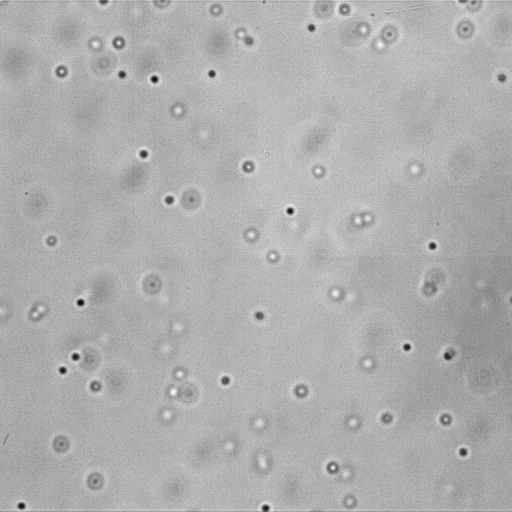

In [4]:
pims_video[1]

In [5]:
import DDM

c:\Users\caggioni.m\Documents\microrheology\microrheology_water_test\DDM.py:50: SyntaxWarning: invalid escape sequence '\D'
  plt.title('(b) image 2 $I(r,t+ \Delta t)$, time: ' + str((framenum+delta)*interval) + ' s')
c:\Users\caggioni.m\Documents\microrheology\microrheology_water_test\DDM.py:57: SyntaxWarning: invalid escape sequence '\D'
  ' s\n $I( q ,t+ \Delta t ) - I(q,t)$')


In [6]:
DDM.browse_images_FFT(pims_video, start_frame=0, end_frame=150)

interactive(children=(IntSlider(value=75, description='framenum', max=150), IntSlider(value=25, description='d…

In [7]:
pims_video=DDM.calculate_DDM(pims_video,naverage=20,numdt=10,interval=0.01,muperpix=0.1, start_frame=0, end_frame=100)

Text(value='', description='current differential frame realization')

Text(value='0', description='current dt')

In [8]:
DDM.explore_iq_dt(pims_video, interval=0.01)

interactive(children=(IntSlider(value=180, description='selectq', max=360, min=1), IntSlider(value=4, descript…

$$g(q,\tau) = A(q) [1-f(q,\tau)] +B(q)$$

$$f(q,\tau) = e^{-Dq^2 \tau}$$

$$ \tau=\frac{D}{q^2}$$

Text(0, 0.5, 'q')

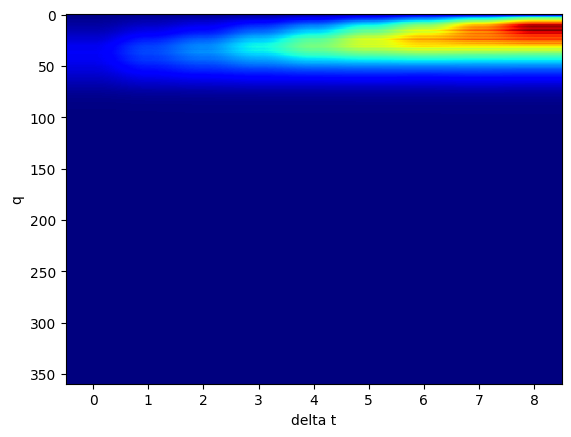

In [14]:
plt.imshow(pims_video.result_FFT.transpose(),cmap='jet',aspect='auto')
plt.xlabel("delta t")
plt.ylabel('q')

0.0008179639702076525


0.0008179639702076525

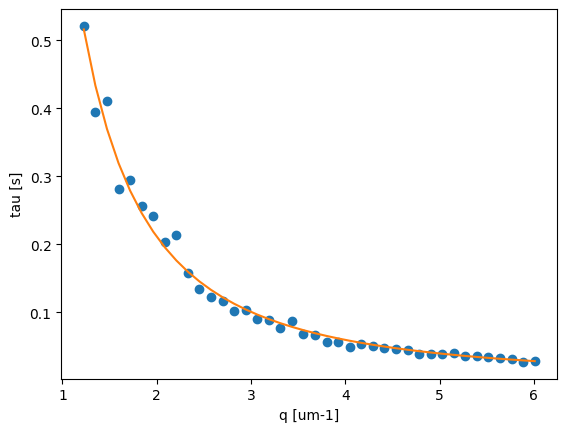

In [15]:
DDM.calculate_viscosity(pims_video,radius=0.2,muperpix=0.1,qmin=10,qmax=50)